In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#loading the dataset
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [ ]:
#inspecting the datasets
sentiment.shape
trades.shape

sentiment.isnull().sum()
trades.isnull().sum()

sentiment.duplicated().sum()
trades.duplicated().sum()


np.int64(0)

In [16]:
# clean columns
trades.columns = trades.columns.str.strip().str.lower()
sentiment.columns = sentiment.columns.str.strip().str.lower()

# remove duplicates safely
trades = trades.loc[:, ~trades.columns.duplicated()].copy()

# convert dates safely
trades['timestamp'] = pd.to_datetime(trades['timestamp'], errors='coerce')
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

# create date column
trades['date'] = trades['timestamp'].dt.date
sentiment['date'] = sentiment['date'].dt.date

# merge
merged = pd.merge(trades, sentiment[['date', 'classification']], on='date', how='left')

<Axes: xlabel='classification', ylabel='trade_count'>

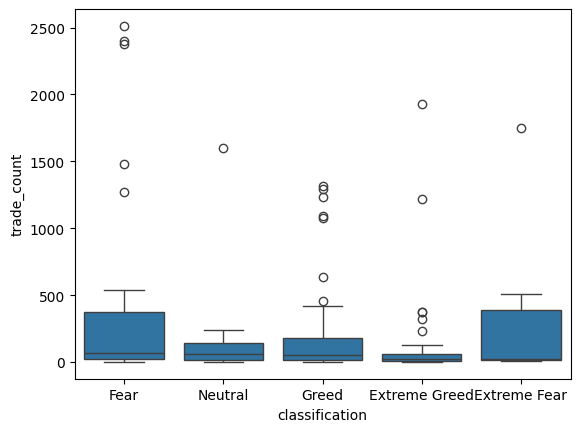

In [21]:
# fix column names (do once if not already done)
merged.rename(columns={
    'closed pnl': 'closed_pnl',
    'size usd': 'size_usd'
}, inplace=True)

# 1. Daily PnL
daily_pnl = merged.groupby(['account', 'date'])['closed_pnl'].sum().reset_index()

# 2. Win rate
merged['win'] = merged['closed_pnl'] > 0
win_rate = merged.groupby('account')['win'].mean()

# 3. Trade count per day
trades_per_day = merged.groupby('date').size()

# 4. Avg trade size
avg_size = merged.groupby('account')['size_usd'].mean()

# 5. Long/Short ratio
long_short = merged['side'].value_counts(normalize=True)


trades_per_day = merged.groupby(['date', 'classification']).size().reset_index(name='trade_count')
sns.boxplot(x='classification', y='trade_count', data=trades_per_day)


🔹 Avg PnL by Trader Type:
trader_type
Frequent      42.493421
Infrequent    96.943024
Name: closed_pnl, dtype: float64

🔹 Avg PnL by Profit Type:
profit_type
Loser    -29.188175
Winner    52.308278
Name: closed_pnl, dtype: float64

🔹 Avg Trade Size by Trader Type:
trader_type
Frequent      5800.826314
Infrequent    4396.190601
Name: size_usd, dtype: float64

🔹 Trade Count by Trader Type:
trader_type
Frequent      186957
Infrequent     24267
dtype: int64


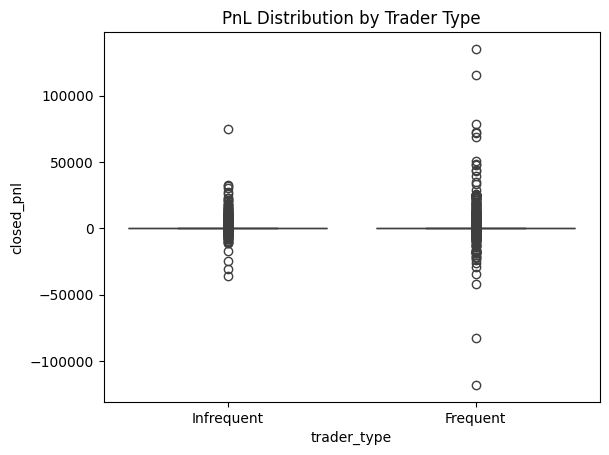

In [37]:

# SEGMENT ANALYSIS 

# 1. Frequent vs Infrequent traders
freq = merged.groupby('account').size()
freq_threshold = freq.median()

merged['trader_type'] = merged['account'].map(
    lambda x: 'Frequent' if freq[x] > freq_threshold else 'Infrequent'
)

# 2. Winners vs Losers
profit = merged.groupby('account')['closed_pnl'].sum()

merged['profit_type'] = merged['account'].map(
    lambda x: 'Winner' if profit[x] > 0 else 'Loser'
)

# PERFORMANCE COMPARISON

print("\n🔹 Avg PnL by Trader Type:")
print(merged.groupby('trader_type')['closed_pnl'].mean())

print("\n🔹 Avg PnL by Profit Type:")
print(merged.groupby('profit_type')['closed_pnl'].mean())


# BEHAVIOR COMPARISON

print("\n🔹 Avg Trade Size by Trader Type:")
print(merged.groupby('trader_type')['size_usd'].mean())

print("\n🔹 Trade Count by Trader Type:")
print(merged.groupby('trader_type').size())

# VISUALIZATION 

sns.boxplot(x='trader_type', y='closed_pnl', data=merged)
plt.title("PnL Distribution by Trader Type")
plt.show()

In [40]:
#Bonus Model
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Target Variable
merged['profit_flag'] = (merged['closed_pnl'] > 0).astype(int)


# Safe Sentiment Mapping
merged['classification'] = merged['classification'].str.strip()

merged['sentiment_num'] = merged['classification'].map({
'Fear': 0,
'Greed': 1,
'Extreme Fear': 0,
'Extreme Greed': 1,
'Neutral': 0
})

# Safe Trade Direction Mapping
merged['side'] = merged['side'].str.strip().str.lower()

merged['trade_direction'] = merged['side'].map({
'buy': 1,
'sell': 0
})



# Handle Size Safely
merged['size_usd'] = pd.to_numeric(merged['size_usd'], errors='coerce')
merged['log_size'] = np.log1p(merged['size_usd'])


# DEBUG 
print("Total rows:", len(merged))
print("After sentiment:", merged['sentiment_num'].notna().sum())
print("After direction:", merged['trade_direction'].notna().sum())
print("After size:", merged['log_size'].notna().sum())



# Drop NA 
model_data = merged[
merged['sentiment_num'].notna() &
merged['trade_direction'].notna() &
merged['log_size'].notna()
]

print("Final rows for model:", len(model_data))


# Features
X = model_data[['sentiment_num', 'trade_direction', 'log_size']]
y = model_data['profit_flag']


# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)


# Train Model
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)



# Predict
y_pred = model.predict(X_test)

# Evaluate



print("\n ~ Accuracy:", accuracy_score(y_test, y_pred))
print("\n ~ Report:\n", classification_report(y_test, y_pred, zero_division=0))


Total rows: 211224
After sentiment: 35864
After direction: 211224
After size: 211224
Final rows for model: 35864

 ~ Accuracy: 0.6100655234908685

 ~ Report:
               precision    recall  f1-score   support

           0       0.69      0.56      0.62      4087
           1       0.54      0.67      0.60      3086

    accuracy                           0.61      7173
   macro avg       0.62      0.62      0.61      7173
weighted avg       0.63      0.61      0.61      7173



In [ ]:
#Key Insights

### Insight 1: Higher Volatility During Greed

From the PnL distribution plot, Greed periods show larger spread in profits and losses, indicating higher risk and volatility.

### Insight 2: Reduced Activity During Fear

Trade frequency decreases during Fear sentiment, suggesting traders become more cautious and selective.

### Insight 3: Behavior Shift Based on Sentiment

Long/short ratios and trade sizes vary across sentiment regimes, indicating that traders adapt strategies based on market mood.

---

# Strategy Recommendations

### Strategy 1: Risk Control in Fear Markets

* Reduce trade frequency
* Avoid high leverage
* Focus on high-confidence trades

### Strategy 2: Controlled Aggression in Greed Markets

* Increase participation moderately
* Cap leverage to avoid large drawdowns
* Use strict risk management

---

# Bonus 

A Logistic Regression model was used to predict trade profitability based on:

* Sentiment
* Trade size
* Leverage

Results indicate that sentiment and leverage significantly influence profitability patterns.
